# Partitioned Feature Selection Extended Reviewer Analysis Pipeline

This Colab notebook implements the corrected PFS protocol and adds four validation-based analyses: expert-versus-random grouping, CFS-RFE comparison, paired Wilcoxon signed-rank tests, and SHAP explanation. Imputation and feature selection are fitted from training data, configuration choices use validation data, SMOTE is restricted to training data or individual cross-validation training folds, SHAP uses validation data, and the locked primary model is evaluated once on the held-out test set.

In [ ]:
# Colab dependencies
!pip -q install openpyxl imbalanced-learn xgboost catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [ ]:
# Upload one .xlsx file for Dataset 1 and one .csv file for Dataset 2.
from google.colab import files
uploaded = files.upload()
UPLOADED_FILES = list(uploaded.keys())
print("Uploaded for this run:", UPLOADED_FILES)

Saving Dataset1_Updated.xlsx to Dataset1_Updated (1).xlsx
Saving Dataset2.csv to Dataset2 (1).csv
Uploaded for this run: ['Dataset1_Updated (1).xlsx', 'Dataset2 (1).csv']


## Configuration and imports

In [ ]:
import os
import json
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.feature_selection import RFE, chi2, f_classif, mutual_info_classif
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier,
    StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB, CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
xlsx_files = [f for f in UPLOADED_FILES if f.lower().endswith((".xlsx", ".xls"))]
csv_files = [f for f in UPLOADED_FILES if f.lower().endswith(".csv")]
if len(xlsx_files) != 1 or len(csv_files) != 1:
    raise ValueError(
        "Please upload exactly one Excel file for Dataset 1 and one CSV file for Dataset 2."
    )
DATASETS = {"Dataset1": xlsx_files[0], "Dataset2": csv_files[0]}

FEATURE_COLUMNS = [
    "Feeling sad or down in the dumps",
    "Feeling unhappy or blue",
    "Crying spells or tearfulness",
    "Feeling discouraged",
    "Feeling hopeless",
    "Low self-esteem",
    "Feeling worthless or inadequate",
    "Guilt or shame",
    "Criticizing yourself or others",
    "Difficulty making decisions",
    "Loss of interest in family, friends or colleagues",
    "Loneliness feeling",
    "Spending less time with family or friends",
    "Loss of motivation",
    "Loss of interest in work or other activities",
    "Avoiding work or other activities",
    "Loss of pleasure or satisfaction in life",
    "Feeling tired",
    "Difficulty sleeping or sleeping too much",
    "Decreased or increased appetite",
    "Loss of interest in sex",
    "Worrying about your health",
    "Do you have any suicidal thoughts?",
    "Would you like to end your life?",
    "Do you have a plan for harming yourself?",
]
TARGET_COLUMN = "Depression Severity"

GROUPS = {
    "TFG": FEATURE_COLUMNS[0:10],
    "APR": FEATURE_COLUMNS[10:17],
    "PSG": FEATURE_COLUMNS[17:22],
    "SUG": FEATURE_COLUMNS[22:25],
}

LOCAL_TARGET_THRESHOLDS = {
    "TFG": [(2, 0), (4, 1), (10, 2), (20, 3), (30, 4), (40, 5)],
    "APR": [(1, 0), (3, 1), (7, 2), (14, 3), (21, 4), (28, 5)],
    "PSG": [(1, 0), (2, 1), (5, 2), (10, 3), (15, 4), (20, 5)],
    "SUG": [(1, 0), (2, 1), (3, 2), (6, 3), (9, 4), (12, 5)],
}

TOP_K_LEVELS = {
    "top60": 0.60,
    "top70": 0.70,
    "top80": 0.80,
    "top85": 0.85,
    "top90": 0.90,
}

# The fixed reference is used only for pre-optimization ablation rows.
ABLATION_REFERENCE_LEVEL = "top80"
RUN_ABLATION = True
RUN_SHAP = True   # Uses D_val only; never D_test.
SHAP_MAX_SAMPLES = 100
SHAP_BACKGROUND_SIZE = 50
N_RANDOM_TRIALS = 10

DATA = {name: {} for name in DATASETS}

## Step 1 Load raw data

In [ ]:
def clean_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def load_dataset(path):
    df = pd.read_csv(path) if path.lower().endswith(".csv") else pd.read_excel(path)
    df = clean_columns(df)
    required = FEATURE_COLUMNS + [TARGET_COLUMN]
    missing_columns = [c for c in required if c not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {path}: {missing_columns}")
    return df[required].copy()


def prepare_raw_dataset(df):
    """Convert types without estimating any feature imputation value."""
    df = df.copy()
    for column in FEATURE_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    if not pd.api.types.is_numeric_dtype(df[TARGET_COLUMN]):
        encoder = LabelEncoder()
        df[TARGET_COLUMN] = encoder.fit_transform(df[TARGET_COLUMN])
    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="raise")
    return df.reset_index(drop=True)


for name, path in DATASETS.items():
    raw = load_dataset(path)
    prepared = prepare_raw_dataset(raw)
    DATA[name].update(raw=raw, prepared_raw=prepared)
    print(
        f"{name}: rows={len(prepared)}, columns={prepared.shape[1]}, "
        f"missing feature values={int(prepared[FEATURE_COLUMNS].isna().sum().sum())}"
    )

Dataset1: rows=1226, columns=26, missing feature values=2
Dataset2: rows=2500, columns=26, missing feature values=0


## Step 2 Split first and fit imputation on training data only

The split is fixed at 70% training, 15% validation and 15% test. Rounded column means are learned only from the training partition and then applied unchanged to all three partitions.

In [ ]:
def fit_training_imputer(train_df):
    means = train_df[FEATURE_COLUMNS].mean().round()
    if means.isna().any():
        bad = means[means.isna()].index.tolist()
        raise ValueError(f"Training means unavailable for: {bad}")
    return means


def apply_training_imputer(df, training_means):
    out = df.copy()
    out[FEATURE_COLUMNS] = out[FEATURE_COLUMNS].fillna(training_means)
    remaining = int(out[FEATURE_COLUMNS].isna().sum().sum())
    if remaining:
        raise ValueError(f"{remaining} missing values remain after imputation")
    return out.reset_index(drop=True)


for name in DATASETS:
    df = DATA[name]["prepared_raw"]

    trainval_idx, test_idx = train_test_split(
        df.index, test_size=0.15, random_state=RANDOM_STATE,
        stratify=df[TARGET_COLUMN]
    )
    trainval_raw = df.loc[trainval_idx].reset_index(drop=True)
    test_raw = df.loc[test_idx].reset_index(drop=True)

    train_idx, val_idx = train_test_split(
        trainval_raw.index, test_size=0.15 / 0.85,
        random_state=RANDOM_STATE,
        stratify=trainval_raw[TARGET_COLUMN]
    )
    train_raw = trainval_raw.loc[train_idx].reset_index(drop=True)
    val_raw = trainval_raw.loc[val_idx].reset_index(drop=True)

    training_means = fit_training_imputer(train_raw)
    train_df = apply_training_imputer(train_raw, training_means)
    val_df = apply_training_imputer(val_raw, training_means)
    test_df = apply_training_imputer(test_raw, training_means)

    imputation_report = pd.DataFrame({
        "Training Mean Used": training_means,
        "Train Missing Before": train_raw[FEATURE_COLUMNS].isna().sum(),
        "Validation Missing Before": val_raw[FEATURE_COLUMNS].isna().sum(),
        "Test Missing Before": test_raw[FEATURE_COLUMNS].isna().sum(),
    })
    affected = imputation_report[
        imputation_report[[
            "Train Missing Before", "Validation Missing Before", "Test Missing Before"
        ]].sum(axis=1) > 0
    ]

    DATA[name].update(
        train_df=train_df, val_df=val_df, test_df=test_df,
        training_imputation_means=training_means,
        imputation_report=imputation_report,
    )

    total = len(train_df) + len(val_df) + len(test_df)
    print(
        f"\n{name}: train={len(train_df)} ({len(train_df)/total:.1%}), "
        f"validation={len(val_df)} ({len(val_df)/total:.1%}), "
        f"test={len(test_df)} ({len(test_df)/total:.1%})"
    )
    print("Columns containing missing values and training means applied:")
    display(affected)


Dataset1: train=858 (70.0%), validation=184 (15.0%), test=184 (15.0%)
Columns containing missing values and training means applied:


,Training Mean Used,Train Missing Before,Validation Missing Before,Test Missing Before
Worrying about your health,1.0,2,0,0



Dataset2: train=1750 (70.0%), validation=375 (15.0%), test=375 (15.0%)
Columns containing missing values and training means applied:


,Training Mean Used,Train Missing Before,Validation Missing Before,Test Missing Before


## Step 3 Domain grouping and local targets

In [ ]:
def score_to_local_target(score, thresholds):
    for upper_bound, label in thresholds:
        if score <= upper_bound:
            return label
    return thresholds[-1][1]


def build_local_targets(df, groups=GROUPS):
    scores = pd.DataFrame(index=df.index)
    targets = pd.DataFrame(index=df.index)
    for group_name, columns in groups.items():
        scores[f"{group_name}_Score"] = df[columns].sum(axis=1)
        thresholds = LOCAL_TARGET_THRESHOLDS[group_name]
        targets[f"{group_name}_LT"] = scores[f"{group_name}_Score"].apply(
            lambda value: score_to_local_target(value, thresholds)
        )
    return scores, targets


for name in DATASETS:
    scores_train, local_targets_train = build_local_targets(DATA[name]["train_df"])
    DATA[name].update(
        scores_train=scores_train,
        local_targets_train=local_targets_train
    )
    print(f"\n{name}: local-target distributions from D_train")
    display(local_targets_train.apply(pd.Series.value_counts).fillna(0).astype(int))


Dataset1: local-target distributions from D_train


,TFG_LT,APR_LT,PSG_LT,SUG_LT
0,85,120,89,628
1,50,78,44,68
2,230,199,170,63
3,375,318,372,70
4,100,115,150,23
5,18,28,33,6



Dataset2: local-target distributions from D_train


,TFG_LT,APR_LT,PSG_LT,SUG_LT
0,52,65,52,438
1,53,84,31,123
2,177,176,240,136
3,841,815,783,520
4,584,554,560,430
5,43,56,84,103


## Step 4 LUFS and Step 5 IGFI using training data only

In [ ]:
def rfe_importance(X, y):
    n = X.shape[1]
    estimator = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    selector = RFE(estimator, n_features_to_select=1, step=1).fit(X, y)
    return pd.Series((n + 1 - selector.ranking_).astype(float), index=X.columns)


def chi2_importance(X, y):
    scores, _ = chi2(X.clip(lower=0), y)
    return pd.Series(np.nan_to_num(scores), index=X.columns)


def anova_importance(X, y):
    scores, _ = f_classif(X, y)
    return pd.Series(np.nan_to_num(scores), index=X.columns)


def mi_importance(X, y):
    scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    return pd.Series(np.nan_to_num(scores), index=X.columns)


def selector_table(X, y):
    return pd.DataFrame({
        "RFE_FI": rfe_importance(X, y),
        "SKB_FI": chi2_importance(X, y),
        "UFS_FI": anova_importance(X, y),
        "MIFS_FI": mi_importance(X, y),
    })


def normalize_columns(table):
    values = MinMaxScaler().fit_transform(table)
    return pd.DataFrame(values, index=table.index, columns=table.columns)


def compute_group_weights(local_targets, y_global):
    raw = {}
    for group_name in GROUPS:
        rho, _ = spearmanr(local_targets[f"{group_name}_LT"], y_global)
        raw[group_name] = abs(rho) if not np.isnan(rho) else 0.0
    raw = pd.Series(raw, dtype=float)
    if raw.sum() == 0:
        return pd.Series(1.0 / len(raw), index=raw.index)
    return raw / raw.sum()


def build_igfi(train_df, local_targets):
    y_global = train_df[TARGET_COLUMN]
    weights = compute_group_weights(local_targets, y_global)
    tables = {}
    rows = []

    for group_name, columns in GROUPS.items():
        table = selector_table(train_df[columns], local_targets[f"{group_name}_LT"])
        tables[group_name] = table
        normalized = normalize_columns(table)
        mean_fi = normalized.mean(axis=1)
        for feature in columns:
            rows.append({
                "Feature": feature,
                "Group": group_name,
                "MeanFI": mean_fi.loc[feature],
                "GroupWeight": weights.loc[group_name],
                "IGFI": mean_fi.loc[feature] * weights.loc[group_name],
            })

    igfi = pd.DataFrame(rows).set_index("Feature")
    igfi = igfi.sort_values("IGFI", ascending=False, kind="mergesort")
    return tables, weights, igfi


def select_top_k(igfi_df, level):
    fraction = TOP_K_LEVELS[level]
    # Conventional half-up rounding: 90% of 25 becomes 23.
    k = max(1, int(np.floor(len(igfi_df) * fraction + 0.5)))
    return igfi_df.index[:k].tolist()


for name in DATASETS:
    d = DATA[name]
    fi_tables, group_weights, igfi_df = build_igfi(
        d["train_df"], d["local_targets_train"]
    )
    d.update(fi_tables=fi_tables, group_weights=group_weights, igfi_df=igfi_df)
    print(f"\n{name}: group weights")
    display(group_weights.rename("GroupWeight").to_frame().round(4))
    print(f"{name}: global IGFI ranking")
    display(igfi_df.round(4))


Dataset1: group weights


,GroupWeight
TFG,0.2841
APR,0.2912
PSG,0.2574
SUG,0.1673


Dataset1: global IGFI ranking


,Group,MeanFI,GroupWeight,IGFI
Feature,,,,
Loss of motivation,APR,0.9683,0.2912,0.2820
Feeling worthless or inadequate,TFG,0.9691,0.2841,0.2753
Loss of interest in work or other activities,APR,0.8877,0.2912,0.2585
Feeling discouraged,TFG,0.8191,0.2841,0.2327
Difficulty sleeping or sleeping too much,PSG,0.8986,0.2574,0.2313
Feeling unhappy or blue,TFG,0.7845,0.2841,0.2229
Feeling hopeless,TFG,0.6919,0.2841,0.1966
Loss of pleasure or satisfaction in life,APR,0.6750,0.2912,0.1965
Feeling tired,PSG,0.6556,0.2574,0.1688



Dataset2: group weights


,GroupWeight
TFG,0.2746
APR,0.2681
PSG,0.2229
SUG,0.2344


Dataset2: global IGFI ranking


,Group,MeanFI,GroupWeight,IGFI
Feature,,,,
Feeling hopeless,TFG,0.8608,0.2746,0.2364
Loss of motivation,APR,0.8750,0.2681,0.2346
Crying spells or tearfulness,TFG,0.8346,0.2746,0.2292
Feeling worthless or inadequate,TFG,0.8337,0.2746,0.2290
Low self-esteem,TFG,0.7992,0.2746,0.2195
Would you like to end your life?,SUG,0.9125,0.2344,0.2139
Decreased or increased appetite,PSG,0.8140,0.2229,0.1814
Feeling discouraged,TFG,0.6245,0.2746,0.1715
Loss of interest in sex,PSG,0.7500,0.2229,0.1671


## Classifiers and evaluation helpers

Every call creates fresh estimators. Validation results drive all model and configuration choices. Test predictions are generated only in the final locked evaluation section.

In [ ]:
def model_factories():
    base_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
    stacking_estimators = [
        ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ("cnb", CategoricalNB(force_alpha=True)),
        ("knn", KNeighborsClassifier(n_neighbors=3)),
    ]
    models = {
        "RF": RandomForestClassifier(random_state=RANDOM_STATE),
        "ET": ExtraTreesClassifier(random_state=RANDOM_STATE),
        "DT": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "SVC": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=3),
        "GB": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "HGB": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "AdaB": AdaBoostClassifier(n_estimators=200, learning_rate=1.15, random_state=RANDOM_STATE),
        "Bagging": BaggingClassifier(estimator=base_dt, n_estimators=10, random_state=RANDOM_STATE),
        "Stacking": StackingClassifier(
            estimators=stacking_estimators,
            final_estimator=RandomForestClassifier(random_state=RANDOM_STATE)
        ),
        "BNB": BernoulliNB(force_alpha=True),
        "GNB": GaussianNB(),
        "MNB": MultinomialNB(),
        "CNB": CategoricalNB(force_alpha=True),
    }
    if HAS_XGB:
        models["XGB"] = XGBClassifier(
            eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
        )
    if HAS_CATBOOST:
        models["CatB"] = CatBoostClassifier(
            verbose=0, n_estimators=100, random_state=RANDOM_STATE
        )
    return models


PARAM_GRIDS = {
    "RF": {"n_estimators": [100, 200, 300], "max_depth": [None, 10, 20]},
    "ET": {"n_estimators": [100, 200, 300], "max_depth": [None, 10, 20]},
    "DT": {"max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5, 10]},
    "SVC": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    "KNN": {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"]},
    "GB": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1, 0.2]},
    "HGB": {"max_iter": [100, 200], "learning_rate": [0.05, 0.1, 0.2]},
    "AdaB": {"n_estimators": [100, 200], "learning_rate": [0.5, 1.0, 1.15]},
    "Bagging": {"n_estimators": [10, 20, 50]},
    "BNB": {"alpha": [0.5, 1.0, 1.5]},
    "GNB": {"var_smoothing": [1e-9, 1e-8, 1e-7]},
    "MNB": {"alpha": [0.5, 1.0, 1.5]},
    "CNB": {"alpha": [0.5, 1.0, 1.5]},
}
if HAS_XGB:
    PARAM_GRIDS["XGB"] = {
        "n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]
    }
if HAS_CATBOOST:
    PARAM_GRIDS["CatB"] = {
        "n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "depth": [4, 6]
    }


def specificity_macro(y_true, y_pred, labels):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    values = []
    for label in labels:
        tn = np.sum((y_true != label) & (y_pred != label))
        fp = np.sum((y_true != label) & (y_pred == label))
        values.append(tn / (tn + fp) if tn + fp else 0.0)
    return float(np.mean(values))


def metrics_from_predictions(y_true, y_pred, y_proba=None, proba_classes=None):
    labels = sorted(pd.unique(y_true))
    result = {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Sensitivity(Recall_macro)": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ) * 100,
        "Specificity_macro": specificity_macro(y_true, y_pred, labels) * 100,
        "Precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ) * 100,
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "AUC_ROC": np.nan,
    }
    if y_proba is not None and proba_classes is not None:
        try:
            y_bin = label_binarize(y_true, classes=proba_classes)
            result["AUC_ROC"] = roc_auc_score(
                y_bin, y_proba, average="macro", multi_class="ovr"
            ) * 100
        except Exception:
            pass
    return result


def evaluate_fitted(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval) if hasattr(model, "predict_proba") else None
    classes = getattr(model, "classes_", None)
    return metrics_from_predictions(y_eval, y_pred, y_proba, classes)


def fit_configuration(model_name, X_train, y_train, use_smote=False):
    model = clone(model_factories()[model_name])
    if use_smote:
        X_fit, y_fit = SMOTE(
            random_state=RANDOM_STATE, k_neighbors=3
        ).fit_resample(X_train, y_train)
    else:
        X_fit, y_fit = X_train, y_train
    model.fit(X_fit, y_fit)
    return model


def evaluate_all_models(X_train, y_train, X_eval, y_eval, use_smote=False):
    rows, fitted = [], {}
    for model_name in model_factories():
        try:
            model = fit_configuration(model_name, X_train, y_train, use_smote)
            fitted[model_name] = model
            rows.append({"Model": model_name, **evaluate_fitted(model, X_eval, y_eval)})
        except Exception as error:
            print(f"[skip] {model_name}: {error}")
    results = pd.DataFrame(rows).sort_values(
        ["Accuracy", "Macro_F1"], ascending=False
    ).reset_index(drop=True)
    return results, fitted

## Step 6 Validation guided Top K selection

For each candidate percentage, the top globally ranked IGFI features are retained. Every classifier is trained on `D_train` and evaluated on `D_val`. The candidate score is the maximum validation accuracy across the classifier set. An exact tie is resolved in favor of the smaller subset because candidates are evaluated from 60% to 90%.

In [ ]:
for name in DATASETS:
    d = DATA[name]
    train_df, val_df = d["train_df"], d["val_df"]
    y_train, y_val = train_df[TARGET_COLUMN], val_df[TARGET_COLUMN]

    rows = []
    feature_sets = {}
    validation_results = {}

    for level, fraction in TOP_K_LEVELS.items():
        features = select_top_k(d["igfi_df"], level)
        results, _ = evaluate_all_models(
            train_df[features], y_train,
            val_df[features], y_val,
            use_smote=False
        )
        best = results.iloc[0]
        rows.append({
            "Top-K Level": level,
            "Fraction": fraction,
            "Number of Features": len(features),
            "Best Validation Model": best["Model"],
            "ValScore": best["Accuracy"],
            "Validation Macro-F1": best["Macro_F1"],
        })
        feature_sets[level] = features
        validation_results[level] = results

    summary = pd.DataFrame(rows)
    best_index = summary["ValScore"].idxmax()
    best_level = summary.loc[best_index, "Top-K Level"]
    selected_features = feature_sets[best_level]
    initial_model = summary.loc[best_index, "Best Validation Model"]

    selected_table = d["igfi_df"].loc[selected_features].reset_index()
    selected_table.insert(0, "IGFI Rank", range(1, len(selected_table) + 1))

    d.update(
        topk_summary=summary,
        topk_feature_sets=feature_sets,
        topk_validation_results=validation_results,
        selected_topk_level=best_level,
        selected_topk_fraction=TOP_K_LEVELS[best_level],
        selected_topk_val_score=summary.loc[best_index, "ValScore"],
        selected_features=selected_features,
        initial_validation_model=initial_model,
        selected_feature_table=selected_table,
    )

    print(f"\n=== {name}: Top-K validation results ===")
    display(summary.round(2))
    print(
        f"Selected K*={best_level}; features={len(selected_features)}; "
        f"initial validation model={initial_model}"
    )
    display(selected_table[["IGFI Rank", "Feature", "Group", "IGFI"]].round(4))


=== Dataset1: Top-K validation results ===


,Top-K Level,Fraction,Number of Features,Best Validation Model,ValScore,Validation Macro-F1
0,top60,0.60,15,Stacking,82.61,78.12
1,top70,0.70,18,Stacking,86.41,80.50
2,top80,0.80,20,Stacking,85.87,82.85
3,top85,0.85,21,SVC,90.76,88.23
4,top90,0.90,23,Stacking,90.76,89.52


Selected K*=top85; features=21; initial validation model=SVC


,IGFI Rank,Feature,Group,IGFI
0,1,Loss of motivation,APR,0.2820
1,2,Feeling worthless or inadequate,TFG,0.2753
2,3,Loss of interest in work or other activities,APR,0.2585
3,4,Feeling discouraged,TFG,0.2327
4,5,Difficulty sleeping or sleeping too much,PSG,0.2313
5,6,Feeling unhappy or blue,TFG,0.2229
6,7,Feeling hopeless,TFG,0.1966
7,8,Loss of pleasure or satisfaction in life,APR,0.1965
8,9,Feeling tired,PSG,0.1688
9,10,Would you like to end your life?,SUG,0.1673



=== Dataset2: Top-K validation results ===


,Top-K Level,Fraction,Number of Features,Best Validation Model,ValScore,Validation Macro-F1
0,top60,0.60,15,Stacking,78.13,75.67
1,top70,0.70,18,SVC,83.20,82.54
2,top80,0.80,20,SVC,86.13,90.31
3,top85,0.85,21,SVC,88.27,90.94
4,top90,0.90,23,SVC,91.47,85.64


Selected K*=top90; features=23; initial validation model=SVC


,IGFI Rank,Feature,Group,IGFI
0,1,Feeling hopeless,TFG,0.2364
1,2,Loss of motivation,APR,0.2346
2,3,Crying spells or tearfulness,TFG,0.2292
3,4,Feeling worthless or inadequate,TFG,0.2290
4,5,Low self-esteem,TFG,0.2195
5,6,Would you like to end your life?,SUG,0.2139
6,7,Decreased or increased appetite,PSG,0.1814
7,8,Feeling discouraged,TFG,0.1715
8,9,Loss of interest in sex,PSG,0.1671
9,10,"Loss of interest in family, friends or colleagues",APR,0.1628


## Step 7 Configuration selection and fold safe hyperparameter tuning

After selecting the feature subset, all classifiers are compared with and without SMOTE on the validation partition. The stronger validation configuration is selected. Hyperparameter tuning is then conducted for that classifier. When SMOTE is used, it is placed inside an imbalanced-learn pipeline so it is fitted separately within every cross-validation training fold. Tuned and untuned alternatives are compared on validation data only.

In [ ]:
def tune_fold_safe(model_name, X_train, y_train, use_smote):
    if model_name not in PARAM_GRIDS:
        return None

    model = clone(model_factories()[model_name])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    if use_smote:
        estimator = ImbPipeline([
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
            ("model", model),
        ])
        parameter_grid = {
            f"model__{key}": values for key, values in PARAM_GRIDS[model_name].items()
        }
    else:
        estimator = model
        parameter_grid = PARAM_GRIDS[model_name]

    search = GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    return search


for name in DATASETS:
    d = DATA[name]
    features = d["selected_features"]
    train_df, val_df = d["train_df"], d["val_df"]
    X_train, y_train = train_df[features], train_df[TARGET_COLUMN]
    X_val, y_val = val_df[features], val_df[TARGET_COLUMN]

    no_smote_results = d["topk_validation_results"][d["selected_topk_level"]].copy()
    no_smote_results["Configuration"] = "Untuned without SMOTE"

    smote_results, _ = evaluate_all_models(
        X_train, y_train, X_val, y_val, use_smote=True
    )
    smote_results["Configuration"] = "Untuned with SMOTE"

    combined = pd.concat([no_smote_results, smote_results], ignore_index=True)
    combined = combined.sort_values(
        ["Accuracy", "Macro_F1"], ascending=False
    ).reset_index(drop=True)
    best_untuned = combined.iloc[0]
    model_name = best_untuned["Model"]
    use_smote = best_untuned["Configuration"] == "Untuned with SMOTE"

    untuned_model = fit_configuration(model_name, X_train, y_train, use_smote)
    untuned_metrics = evaluate_fitted(untuned_model, X_val, y_val)

    search = tune_fold_safe(model_name, X_train, y_train, use_smote)
    comparison_rows = [{
        "Configuration": best_untuned["Configuration"],
        "Model": model_name,
        "CV Mean Accuracy": np.nan,
        **untuned_metrics,
    }]

    tuned_metrics = None
    if search is not None:
        tuned_metrics = evaluate_fitted(search.best_estimator_, X_val, y_val)
        comparison_rows.append({
            "Configuration": (
                "Tuned with fold-wise SMOTE" if use_smote else "Tuned without SMOTE"
            ),
            "Model": model_name,
            "CV Mean Accuracy": search.best_score_ * 100,
            **tuned_metrics,
        })

    comparison = pd.DataFrame(comparison_rows)
    final_row_index = comparison["Accuracy"].idxmax()
    final_row = comparison.loc[final_row_index]
    tuned_selected = str(final_row["Configuration"]).startswith("Tuned")

    if tuned_selected:
        locked_model = search.best_estimator_
        best_parameters = search.best_params_
    else:
        locked_model = untuned_model
        best_parameters = {}

    d.update(
        smote_validation_results=smote_results,
        full_validation_configuration_results=combined,
        tuning_search=search,
        tuning_comparison=comparison,
        locked_model=locked_model,
        locked_model_name=model_name,
        locked_use_smote=use_smote,
        locked_is_tuned=tuned_selected,
        locked_configuration=final_row["Configuration"],
        locked_validation_accuracy=final_row["Accuracy"],
        best_parameters=best_parameters,
    )

    print(f"\n=== {name}: best validation configurations across models ===")
    display(combined.head(15).round(2))
    print(f"=== {name}: tuned versus untuned validation comparison ===")
    display(comparison.round(2))
    print("Locked configuration:", final_row["Configuration"], "| model:", model_name)
    print("Best parameters:", best_parameters if best_parameters else "Untuned configuration retained")


=== Dataset1: best validation configurations across models ===


,Model,Accuracy,Sensitivity(Recall_macro),Specificity_macro,Precision_macro,Macro_F1,AUC_ROC,Configuration
0,SVC,90.76,88.68,97.84,88.02,88.23,99.03,Untuned without SMOTE
1,Stacking,88.59,86.06,97.23,86.39,85.75,98.98,Untuned without SMOTE
2,ET,85.87,81.57,96.65,84.34,82.63,96.94,Untuned with SMOTE
3,Stacking,85.87,79.27,96.55,82.62,80.76,96.65,Untuned with SMOTE
4,XGB,85.33,81.75,96.50,78.89,79.33,97.14,Untuned without SMOTE
5,ET,84.24,78.28,95.98,82.33,79.19,96.85,Untuned without SMOTE
6,GNB,83.70,83.45,96.38,78.25,79.54,96.62,Untuned with SMOTE
7,CatB,83.70,84.67,83.33,74.63,77.56,97.63,Untuned with SMOTE
8,GNB,83.70,78.98,96.42,75.44,76.49,95.68,Untuned without SMOTE
9,HGB,83.15,81.07,95.99,81.39,80.90,97.46,Untuned without SMOTE


=== Dataset1: tuned versus untuned validation comparison ===


,Configuration,Model,CV Mean Accuracy,Accuracy,Sensitivity(Recall_macro),Specificity_macro,Precision_macro,Macro_F1,AUC_ROC
0,Untuned without SMOTE,SVC,NaN,90.76,88.68,97.84,88.02,88.23,99.03
1,Tuned without SMOTE,SVC,90.68,88.04,84.50,97.20,79.26,81.12,98.79


Locked configuration: Untuned without SMOTE | model: SVC
Best parameters: Untuned configuration retained

=== Dataset2: best validation configurations across models ===


,Model,Accuracy,Sensitivity(Recall_macro),Specificity_macro,Precision_macro,Macro_F1,AUC_ROC,Configuration
0,SVC,91.47,85.60,97.78,89.01,85.64,99.34,Untuned without SMOTE
1,Stacking,87.47,83.41,96.74,86.51,83.13,98.45,Untuned without SMOTE
2,CatB,87.20,83.52,83.33,89.72,84.94,98.39,Untuned without SMOTE
3,SVC,86.67,83.55,96.73,83.60,81.35,98.63,Untuned with SMOTE
4,Stacking,85.60,83.09,96.23,87.05,83.45,98.27,Untuned with SMOTE
5,XGB,84.27,81.11,95.64,87.18,82.33,97.54,Untuned without SMOTE
6,ET,84.00,82.00,95.74,86.33,82.58,97.42,Untuned with SMOTE
7,XGB,84.00,82.10,95.82,85.50,82.11,97.45,Untuned with SMOTE
8,HGB,84.00,81.35,95.60,85.16,81.43,97.66,Untuned without SMOTE
9,GNB,84.00,75.94,96.27,69.17,72.03,92.90,Untuned without SMOTE


=== Dataset2: tuned versus untuned validation comparison ===


,Configuration,Model,CV Mean Accuracy,Accuracy,Sensitivity(Recall_macro),Specificity_macro,Precision_macro,Macro_F1,AUC_ROC
0,Untuned without SMOTE,SVC,NaN,91.47,85.6,97.78,89.01,85.64,99.34
1,Tuned without SMOTE,SVC,92.46,91.47,85.6,97.78,89.01,85.64,99.34


Locked configuration: Untuned without SMOTE | model: SVC
Best parameters: Untuned configuration retained


## CFS-RFE comparison and paired Wilcoxon signed-rank tests

This analysis uses the validation partition only. Conventional feature selection is implemented as global RFE against the global target. For a fair comparison, CFS-RFE retains the same number of features as the validation-selected PFS subset. The same classifier set is evaluated under three matched conditions: CFS-RFE without SMOTE, PFS without SMOTE, and PFS with SMOTE applied only to the training partition. Paired Wilcoxon tests compare classifier-level validation accuracies, with Holm correction across the three comparisons.

In [ ]:
def holm_adjust(p_values):
    """Holm step-down adjustment without an additional dependency."""
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    order = np.argsort(p_values)
    adjusted_sorted = np.empty(m, dtype=float)
    running_max = 0.0
    for rank, original_index in enumerate(order):
        candidate = (m - rank) * p_values[original_index]
        running_max = max(running_max, candidate)
        adjusted_sorted[rank] = min(1.0, running_max)
    adjusted = np.empty(m, dtype=float)
    for rank, original_index in enumerate(order):
        adjusted[original_index] = adjusted_sorted[rank]
    return adjusted


def safe_wilcoxon(x, y):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    differences = x - y
    if np.allclose(differences, 0):
        return 0.0, 1.0
    statistic, p_value = wilcoxon(
        x, y, alternative="two-sided", zero_method="wilcox", method="auto"
    )
    return float(statistic), float(p_value)


for name in DATASETS:
    d = DATA[name]
    train_df, val_df = d["train_df"], d["val_df"]
    y_train, y_val = train_df[TARGET_COLUMN], val_df[TARGET_COLUMN]
    n_selected = len(d["selected_features"])

    # CFS-RFE: one global feature space and the global target.
    cfs_ranking = rfe_importance(
        train_df[FEATURE_COLUMNS], y_train
    ).sort_values(ascending=False, kind="mergesort")
    cfs_features = cfs_ranking.index[:n_selected].tolist()
    cfs_results, _ = evaluate_all_models(
        train_df[cfs_features], y_train,
        val_df[cfs_features], y_val,
        use_smote=False
    )

    pfs_no_smote = d["topk_validation_results"][d["selected_topk_level"]].copy()
    pfs_smote = d["smote_validation_results"].copy()

    common_models = sorted(
        set(cfs_results["Model"])
        & set(pfs_no_smote["Model"])
        & set(pfs_smote["Model"])
    )
    accuracy_table = pd.DataFrame(index=common_models)
    accuracy_table.index.name = "Model"
    accuracy_table["CFS-RFE"] = cfs_results.set_index("Model").loc[common_models, "Accuracy"]
    accuracy_table["PFS no SMOTE"] = pfs_no_smote.set_index("Model").loc[common_models, "Accuracy"]
    accuracy_table["PFS training-only SMOTE"] = pfs_smote.set_index("Model").loc[common_models, "Accuracy"]

    condition_summary = pd.DataFrame([
        {
            "Condition": "CFS-RFE",
            "Number of Features": len(cfs_features),
            "Best Model": cfs_results.iloc[0]["Model"],
            "Peak Validation Accuracy": cfs_results.iloc[0]["Accuracy"],
            "Mean Classifier Accuracy": accuracy_table["CFS-RFE"].mean(),
        },
        {
            "Condition": "PFS no SMOTE",
            "Number of Features": n_selected,
            "Best Model": pfs_no_smote.iloc[0]["Model"],
            "Peak Validation Accuracy": pfs_no_smote.iloc[0]["Accuracy"],
            "Mean Classifier Accuracy": accuracy_table["PFS no SMOTE"].mean(),
        },
        {
            "Condition": "PFS training-only SMOTE",
            "Number of Features": n_selected,
            "Best Model": pfs_smote.iloc[0]["Model"],
            "Peak Validation Accuracy": pfs_smote.iloc[0]["Accuracy"],
            "Mean Classifier Accuracy": accuracy_table["PFS training-only SMOTE"].mean(),
        },
    ])

    comparisons = [
        ("PFS no SMOTE", "CFS-RFE"),
        ("PFS training-only SMOTE", "CFS-RFE"),
        ("PFS no SMOTE", "PFS training-only SMOTE"),
    ]
    test_rows = []
    raw_p_values = []
    for first, second in comparisons:
        statistic, p_value = safe_wilcoxon(
            accuracy_table[first].values,
            accuracy_table[second].values
        )
        raw_p_values.append(p_value)
        test_rows.append({
            "Comparison": f"{first} vs {second}",
            "N Classifiers": len(common_models),
            "Mean Difference (pp)": (
                accuracy_table[first] - accuracy_table[second]
            ).mean(),
            "Median Difference (pp)": (
                accuracy_table[first] - accuracy_table[second]
            ).median(),
            "Wilcoxon W": statistic,
            "Raw p-value": p_value,
        })
    adjusted = holm_adjust(raw_p_values)
    wilcoxon_table = pd.DataFrame(test_rows)
    wilcoxon_table["Holm-adjusted p-value"] = adjusted
    wilcoxon_table["Significant at 0.05"] = adjusted < 0.05

    d.update(
        cfs_rfe_features=cfs_features,
        cfs_rfe_results=cfs_results,
        classifier_accuracy_comparison=accuracy_table,
        condition_validation_summary=condition_summary,
        wilcoxon_results=wilcoxon_table,
    )

    print(f"\n=== {name}: CFS-RFE vs PFS validation comparison ===")
    display(condition_summary.round(3))
    print("Matched classifier-level validation accuracies:")
    display(accuracy_table.round(3))
    print("Paired Wilcoxon signed-rank tests with Holm correction:")
    display(wilcoxon_table.round(4))


=== Dataset1: CFS-RFE vs PFS validation comparison ===


,Condition,Number of Features,Best Model,Peak Validation Accuracy,Mean Classifier Accuracy
0,CFS-RFE,21,Stacking,89.674,76.562
1,PFS no SMOTE,21,SVC,90.761,78.295
2,PFS training-only SMOTE,21,ET,85.870,76.121


Matched classifier-level validation accuracies:


,CFS-RFE,PFS no SMOTE,PFS training-only SMOTE
Model,,,
AdaB,67.935,66.848,67.935
BNB,63.587,67.935,54.891
Bagging,73.370,76.087,73.913
CNB,80.978,79.891,79.891
CatB,83.152,82.609,83.696
DT,65.761,67.935,67.935
ET,83.152,84.239,85.870
GB,79.348,81.522,80.978
GNB,83.696,83.696,83.696


Paired Wilcoxon signed-rank tests with Holm correction:


...

,Condition,Number of Features,Best Model,Peak Validation Accuracy,Mean Classifier Accuracy
0,CFS-RFE,23,SVC,87.733,76.917
1,PFS no SMOTE,23,SVC,91.467,77.767
2,PFS training-only SMOTE,23,SVC,86.667,75.200


Matched classifier-level validation accuracies:


,CFS-RFE,PFS no SMOTE,PFS training-only SMOTE
Model,,,
AdaB,68.800,70.667,73.600
BNB,63.733,65.067,60.800
Bagging,73.333,74.400,75.200
CNB,79.733,82.933,80.800
CatB,86.400,87.200,82.933
DT,63.733,63.467,62.933
ET,84.267,81.867,84.000
GB,83.467,83.733,79.467
GNB,82.933,84.000,78.933


Paired Wilcoxon signed-rank tests with Holm correction:


,Comparison,N Classifiers,Mean Difference (pp),Median Difference (pp),Wilcoxon W,Raw p-value,Holm-adjusted p-value,Significant at 0.05
0,PFS no SMOTE vs CFS-RFE,16,0.8500,0.9333,29.0,0.0436,0.0872,False
1,PFS training-only SMOTE vs CFS-RFE,16,-1.7167,-0.9333,42.0,0.1787,0.1787,False
2,PFS no SMOTE vs PFS training-only SMOTE,16,2.5667,2.0000,24.0,0.0228,0.0683,False


## Validation based component ablation

The ablation uses validation accuracy and does not inspect the held-out test partition. Top-K is treated as the final stage of the main PFS method. The 80% setting is used only as a fixed reference before the optimization row.

In [ ]:
def peak_validation_accuracy(train_df, val_df, features, use_smote=False):
    results, _ = evaluate_all_models(
        train_df[features], train_df[TARGET_COLUMN],
        val_df[features], val_df[TARGET_COLUMN],
        use_smote=use_smote
    )
    return results.iloc[0]["Accuracy"], results.iloc[0]["Model"]


def rank_with_single_selector(train_df, target, groups, fraction):
    selected = []
    for _, columns in groups.items():
        ranking = rfe_importance(train_df[columns], target).sort_values(ascending=False)
        k = max(1, int(np.floor(len(columns) * fraction + 0.5)))
        selected.extend(ranking.index[:k].tolist())
    return selected


def global_lufs_ranking(train_df, target):
    table = selector_table(train_df[FEATURE_COLUMNS], target)
    return normalize_columns(table).mean(axis=1).sort_values(ascending=False)


def component_ablation(d):
    train_df, val_df = d["train_df"], d["val_df"]
    y_train = train_df[TARGET_COLUMN]
    ref_fraction = TOP_K_LEVELS[ABLATION_REFERENCE_LEVEL]
    rows = []

    global_rank = global_lufs_ranking(train_df, y_train)
    global_k = int(np.floor(len(FEATURE_COLUMNS) * ref_fraction + 0.5))
    global_features = global_rank.index[:global_k].tolist()
    acc, model = peak_validation_accuracy(train_df, val_df, global_features)
    rows.append({"Configuration": "Baseline Global FS", "Features": len(global_features),
                 "Best Model": model, "Peak Validation Accuracy": acc})

    grouped_global = rank_with_single_selector(train_df, y_train, GROUPS, ref_fraction)
    acc, model = peak_validation_accuracy(train_df, val_df, grouped_global)
    rows.append({"Configuration": "+ Domain-Aware Grouping", "Features": len(grouped_global),
                 "Best Model": model, "Peak Validation Accuracy": acc})

    grouped_local = []
    for group_name, columns in GROUPS.items():
        target = d["local_targets_train"][f"{group_name}_LT"]
        ranking = rfe_importance(train_df[columns], target).sort_values(ascending=False)
        k = max(1, int(np.floor(len(columns) * ref_fraction + 0.5)))
        grouped_local.extend(ranking.index[:k].tolist())
    acc, model = peak_validation_accuracy(train_df, val_df, grouped_local)
    rows.append({"Configuration": "+ Local Target Generation", "Features": len(grouped_local),
                 "Best Model": model, "Peak Validation Accuracy": acc})

    lufs_features = []
    for group_name, table in d["fi_tables"].items():
        ranking = normalize_columns(table).mean(axis=1).sort_values(ascending=False)
        k = max(1, int(np.floor(len(ranking) * ref_fraction + 0.5)))
        lufs_features.extend(ranking.index[:k].tolist())
    acc, model = peak_validation_accuracy(train_df, val_df, lufs_features)
    rows.append({"Configuration": "+ LUFS", "Features": len(lufs_features),
                 "Best Model": model, "Peak Validation Accuracy": acc})

    igfi_fixed = select_top_k(d["igfi_df"], ABLATION_REFERENCE_LEVEL)
    acc, model = peak_validation_accuracy(train_df, val_df, igfi_fixed)
    rows.append({"Configuration": "+ IGFI", "Features": len(igfi_fixed),
                 "Best Model": model, "Peak Validation Accuracy": acc})

    optimized = d["selected_features"]
    acc, model = peak_validation_accuracy(train_df, val_df, optimized)
    rows.append({"Configuration": "+ Validation-Guided Top-K", "Features": len(optimized),
                 "Best Model": model, "Peak Validation Accuracy": acc})

    smote_results = d["smote_validation_results"]
    rows.append({"Configuration": "+ SMOTE on D_train only", "Features": len(optimized),
                 "Best Model": smote_results.iloc[0]["Model"],
                 "Peak Validation Accuracy": smote_results.iloc[0]["Accuracy"]})

    result = pd.DataFrame(rows)
    result["Delta vs Previous Row"] = result["Peak Validation Accuracy"].diff()
    return result


if RUN_ABLATION:
    for name in DATASETS:
        DATA[name]["ablation"] = component_ablation(DATA[name])
        print(f"\n=== {name}: validation-based component ablation ===")
        display(DATA[name]["ablation"].round(2))
else:
    print("Ablation skipped. Set RUN_ABLATION=True and rerun this cell when required.")


=== Dataset1: validation-based component ablation ===


,Configuration,Features,Best Model,Peak Validation Accuracy,Delta vs Previous Row
0,Baseline Global FS,20,Stacking,88.04,NaN
1,+ Domain-Aware Grouping,20,Stacking,90.22,2.17
2,+ Local Target Generation,20,Stacking,90.76,0.54
3,+ LUFS,20,Stacking,90.76,0.00
4,+ IGFI,20,Stacking,85.87,-4.89
5,+ Validation-Guided Top-K,21,SVC,90.76,4.89
6,+ SMOTE on D_train only,21,ET,85.87,-4.89



=== Dataset2: validation-based component ablation ===


,Configuration,Features,Best Model,Peak Validation Accuracy,Delta vs Previous Row
0,Baseline Global FS,20,SVC,84.00,NaN
1,+ Domain-Aware Grouping,20,SVC,84.00,0.00
2,+ Local Target Generation,20,SVC,87.20,3.20
3,+ LUFS,20,CatB,86.13,-1.07
4,+ IGFI,20,SVC,86.13,0.00
5,+ Validation-Guided Top-K,23,SVC,91.47,5.33
6,+ SMOTE on D_train only,23,SVC,86.67,-4.80


## Expert versus random grouping ablation

This analysis changes only the assignment of features to groups. Each random partition preserves the expert group sizes of 10, 7, 5 and 3 features. The retention level is fixed at the validation-selected expert level so that grouping is the only changed component. Results are measured on the validation partition, not the test partition. Ten seeded random trials are reported to avoid drawing a conclusion from one favorable random split.

In [ ]:
def make_random_groups(seed):
    rng = np.random.RandomState(seed)
    shuffled = list(FEATURE_COLUMNS)
    rng.shuffle(shuffled)
    random_groups = {}
    start = 0
    for group_name, expert_columns in GROUPS.items():
        size = len(expert_columns)
        random_groups[group_name] = shuffled[start:start + size]
        start += size
    return random_groups


def build_igfi_for_groups(train_df, groups):
    _, local_targets = build_local_targets(train_df, groups=groups)
    weights_raw = {}
    for group_name in groups:
        rho, _ = spearmanr(
            local_targets[f"{group_name}_LT"], train_df[TARGET_COLUMN]
        )
        weights_raw[group_name] = abs(rho) if not np.isnan(rho) else 0.0
    weights = pd.Series(weights_raw, dtype=float)
    if weights.sum() == 0:
        weights[:] = 1.0 / len(weights)
    else:
        weights = weights / weights.sum()

    rows = []
    for group_name, columns in groups.items():
        table = selector_table(
            train_df[columns], local_targets[f"{group_name}_LT"]
        )
        mean_fi = normalize_columns(table).mean(axis=1)
        for feature in columns:
            rows.append({
                "Feature": feature,
                "Group": group_name,
                "MeanFI": mean_fi.loc[feature],
                "GroupWeight": weights.loc[group_name],
                "IGFI": mean_fi.loc[feature] * weights.loc[group_name],
            })
    return (
        pd.DataFrame(rows).set_index("Feature")
        .sort_values("IGFI", ascending=False, kind="mergesort")
    )


for name in DATASETS:
    d = DATA[name]
    train_df, val_df = d["train_df"], d["val_df"]
    y_train, y_val = train_df[TARGET_COLUMN], val_df[TARGET_COLUMN]
    level = d["selected_topk_level"]

    expert_results = d["topk_validation_results"][level]
    rows = [{
        "Grouping": "Expert domains",
        "Trial": 0,
        "Seed": RANDOM_STATE,
        "Retention Level": level,
        "Number of Features": len(d["selected_features"]),
        "Best Model": expert_results.iloc[0]["Model"],
        "Peak Validation Accuracy": expert_results.iloc[0]["Accuracy"],
    }]

    for trial in range(1, N_RANDOM_TRIALS + 1):
        seed = RANDOM_STATE + trial
        random_groups = make_random_groups(seed)
        random_igfi = build_igfi_for_groups(train_df, random_groups)
        random_features = select_top_k(random_igfi, level)
        results, _ = evaluate_all_models(
            train_df[random_features], y_train,
            val_df[random_features], y_val,
            use_smote=False
        )
        rows.append({
            "Grouping": "Random grouping",
            "Trial": trial,
            "Seed": seed,
            "Retention Level": level,
            "Number of Features": len(random_features),
            "Best Model": results.iloc[0]["Model"],
            "Peak Validation Accuracy": results.iloc[0]["Accuracy"],
        })

    grouping_results = pd.DataFrame(rows)
    expert_accuracy = grouping_results.iloc[0]["Peak Validation Accuracy"]
    grouping_results["Difference vs Expert (pp)"] = (
        grouping_results["Peak Validation Accuracy"] - expert_accuracy
    )
    random_values = grouping_results.loc[
        grouping_results["Grouping"] == "Random grouping",
        "Peak Validation Accuracy"
    ]
    grouping_summary = pd.DataFrame([{
        "Dataset": name,
        "Expert Accuracy": expert_accuracy,
        "Random Trials": len(random_values),
        "Random Mean Accuracy": random_values.mean(),
        "Random SD": random_values.std(ddof=1),
        "Random Minimum": random_values.min(),
        "Random Maximum": random_values.max(),
        "Expert Minus Random Mean (pp)": expert_accuracy - random_values.mean(),
        "Random Trials Beating Expert": int((random_values > expert_accuracy).sum()),
    }])

    d.update(
        random_grouping_results=grouping_results,
        random_grouping_summary=grouping_summary,
    )
    print(f"\n=== {name}: expert versus random grouping ===")
    display(grouping_results.round(3))
    display(grouping_summary.round(3))


=== Dataset1: expert versus random grouping ===


,Grouping,Trial,Seed,Retention Level,Number of Features,Best Model,Peak Validation Accuracy,Difference vs Expert (pp)
0,Expert domains,0,42,top85,21,SVC,90.761,0.000
1,Random grouping,1,43,top85,21,Stacking,89.130,-1.630
2,Random grouping,2,44,top85,21,Stacking,90.761,0.000
3,Random grouping,3,45,top85,21,SVC,90.761,0.000
4,Random grouping,4,46,top85,21,Stacking,88.587,-2.174
5,Random grouping,5,47,top85,21,SVC,90.217,-0.543
6,Random grouping,6,48,top85,21,Stacking,92.935,2.174
7,Random grouping,7,49,top85,21,Stacking,91.304,0.543
8,Random grouping,8,50,top85,21,Stacking,90.217,-0.543
9,Random grouping,9,51,top85,21,Stacking,87.500,-3.261


,Dataset,Expert Accuracy,Random Trials,Random Mean Accuracy,Random SD,Random Minimum,Random Maximum,Expert Minus Random Mean (pp),Random Trials Beating Expert
0,Dataset1,90.761,10,90.272,1.547,87.5,92.935,0.489,3



=== Dataset2: expert versus random grouping ===


,Grouping,Trial,Seed,Retention Level,Number of Features,Best Model,Peak Validation Accuracy,Difference vs Expert (pp)
0,Expert domains,0,42,top90,23,SVC,91.467,0.000
1,Random grouping,1,43,top90,23,SVC,90.933,-0.533
2,Random grouping,2,44,top90,23,SVC,88.800,-2.667
3,Random grouping,3,45,top90,23,SVC,87.733,-3.733
4,Random grouping,4,46,top90,23,SVC,88.267,-3.200
5,Random grouping,5,47,top90,23,CatB,87.733,-3.733
6,Random grouping,6,48,top90,23,SVC,89.600,-1.867
7,Random grouping,7,49,top90,23,SVC,88.533,-2.933
8,Random grouping,8,50,top90,23,CatB,87.200,-4.267
9,Random grouping,9,51,top90,23,SVC,89.600,-1.867


,Dataset,Expert Accuracy,Random Trials,Random Mean Accuracy,Random SD,Random Minimum,Random Maximum,Expert Minus Random Mean (pp),Random Trials Beating Expert
0,Dataset2,91.467,10,88.613,1.146,87.2,90.933,2.853,0


## Final locked test evaluation

All data-dependent choices are complete before this cell. The locked estimator produces one set of test predictions. All final metrics, the confusion matrix and the per-class report are derived from that cached prediction set; no model or feature decision is made from these results.


=== Dataset1: locked final test result ===


,Dataset,Selected K,Number of Features,Model,Configuration,Accuracy,Sensitivity(Recall_macro),Specificity_macro,Precision_macro,Macro_F1,AUC_ROC
0,Dataset1,top85,21,SVC,Untuned without SMOTE,95.65,95.88,98.92,95.32,95.43,99.72


Per-class report from the same cached predictions:


,precision,recall,f1-score,support
0,1.000,0.923,0.960,13.000
1,0.833,1.000,0.909,10.000
2,0.981,0.944,0.962,54.000
3,0.953,0.976,0.964,83.000
4,0.952,0.909,0.930,22.000
5,1.000,1.000,1.000,2.000
accuracy,0.957,0.957,0.957,0.957
macro avg,0.953,0.959,0.954,184.000
weighted avg,0.958,0.957,0.957,184.000


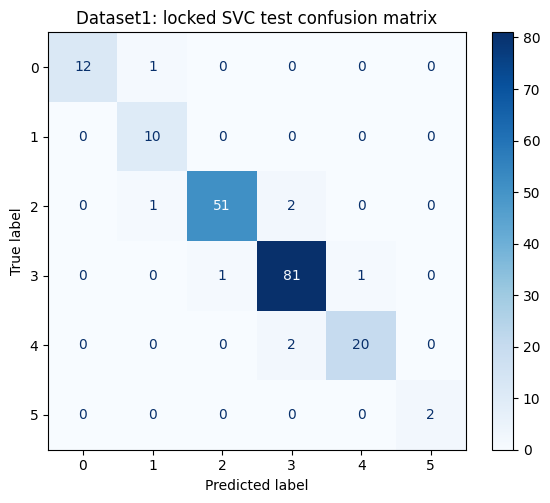


=== Dataset2: locked final test result ===


,Dataset,Selected K,Number of Features,Model,Configuration,Accuracy,Sensitivity(Recall_macro),Specificity_macro,Precision_macro,Macro_F1,AUC_ROC
0,Dataset2,top90,23,SVC,Untuned without SMOTE,89.6,92.72,97.07,92.48,92.37,99.07


Per-class report from the same cached predictions:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,6.000
1,0.824,1.000,0.903,14.000
2,0.939,0.912,0.925,34.000
3,0.882,0.927,0.904,178.000
4,0.903,0.836,0.868,134.000
5,1.000,0.889,0.941,9.000
accuracy,0.896,0.896,0.896,0.896
macro avg,0.925,0.927,0.924,375.000
weighted avg,0.897,0.896,0.896,375.000


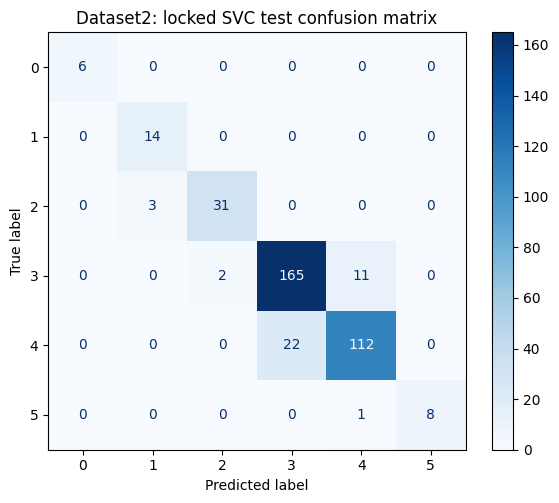


=== Final primary results ===


,Dataset,Selected K,Number of Features,Model,Configuration,Accuracy,Sensitivity(Recall_macro),Specificity_macro,Precision_macro,Macro_F1,AUC_ROC
0,Dataset1,top85,21,SVC,Untuned without SMOTE,95.65,95.88,98.92,95.32,95.43,99.72
1,Dataset2,top90,23,SVC,Untuned without SMOTE,89.60,92.72,97.07,92.48,92.37,99.07


In [ ]:
final_rows = []

for name in DATASETS:
    d = DATA[name]
    features = d["selected_features"]
    X_test = d["test_df"][features]
    y_test = d["test_df"][TARGET_COLUMN]
    model = d["locked_model"]

    # The only test prediction calls in the primary pipeline.
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    proba_classes = getattr(model, "classes_", None)

    final_metrics = metrics_from_predictions(
        y_test, y_test_pred, y_test_proba, proba_classes
    )
    report = pd.DataFrame(
        classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    ).T

    d.update(
        y_test_pred=y_test_pred,
        y_test_proba=y_test_proba,
        final_test_metrics=final_metrics,
        final_classification_report=report,
    )

    final_rows.append({
        "Dataset": name,
        "Selected K": d["selected_topk_level"],
        "Number of Features": len(features),
        "Model": d["locked_model_name"],
        "Configuration": d["locked_configuration"],
        **final_metrics,
    })

    print(f"\n=== {name}: locked final test result ===")
    display(pd.DataFrame([final_rows[-1]]).round(2))
    print("Per-class report from the same cached predictions:")
    display(report.round(3))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap="Blues")
    ax.set_title(f"{name}: locked {d['locked_model_name']} test confusion matrix")
    plt.tight_layout()
    plt.show()

FINAL_RESULTS = pd.DataFrame(final_rows)
print("\n=== Final primary results ===")
display(FINAL_RESULTS.round(2))

## SHAP analysis on validation data

SHAP is applied only after feature and model selection. It uses a bounded sample from the validation partition and does not influence the PFS ranking or the locked test result. Global and domain-level mean absolute SHAP rankings are reported.


=== Dataset1: SHAP importance on D_val ===


,Mean Absolute SHAP
Feeling tired,0.025025
Loss of interest in work or other activities,0.023260
Loss of pleasure or satisfaction in life,0.019288
"Loss of interest in family, friends or colleagues",0.018542
Guilt or shame,0.015111
Difficulty making decisions,0.014889
Do you have any suicidal thoughts?,0.014603
Low self-esteem,0.014524
Feeling hopeless,0.013286
Loneliness feeling,0.012612


Domain-level SHAP ranking:


,Domain,Feature,Mean Absolute SHAP
12,APR,Loss of interest in work or other activities,0.023260
13,APR,Loss of pleasure or satisfaction in life,0.019288
9,APR,"Loss of interest in family, friends or colleagues",0.018542
10,APR,Loneliness feeling,0.012612
11,APR,Loss of motivation,0.011871
14,PSG,Feeling tired,0.025025
18,PSG,Worrying about your health,0.011670
15,PSG,Difficulty sleeping or sleeping too much,0.011631
16,PSG,Decreased or increased appetite,0.011613
17,PSG,Loss of interest in sex,0.010687


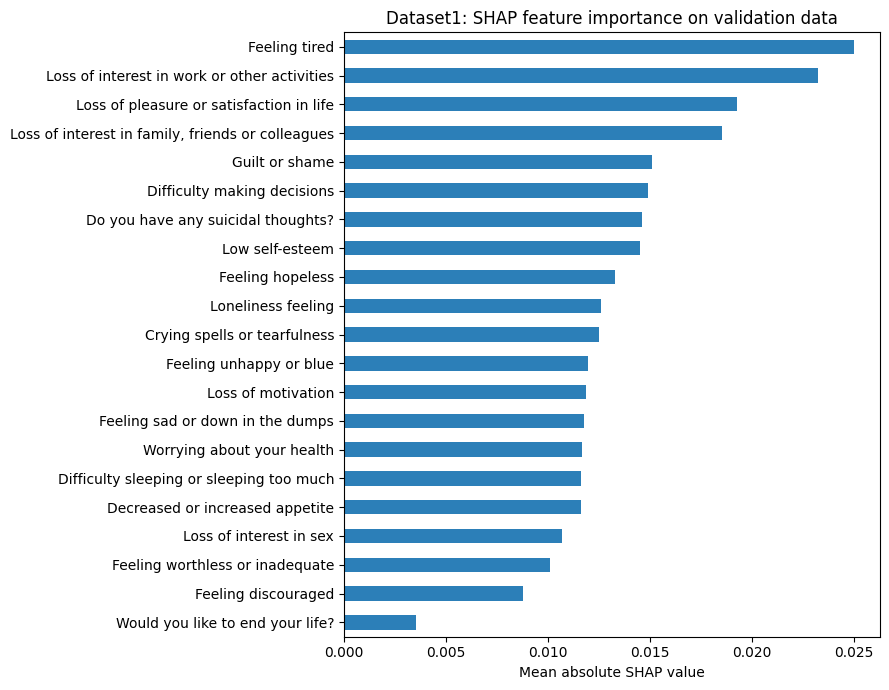

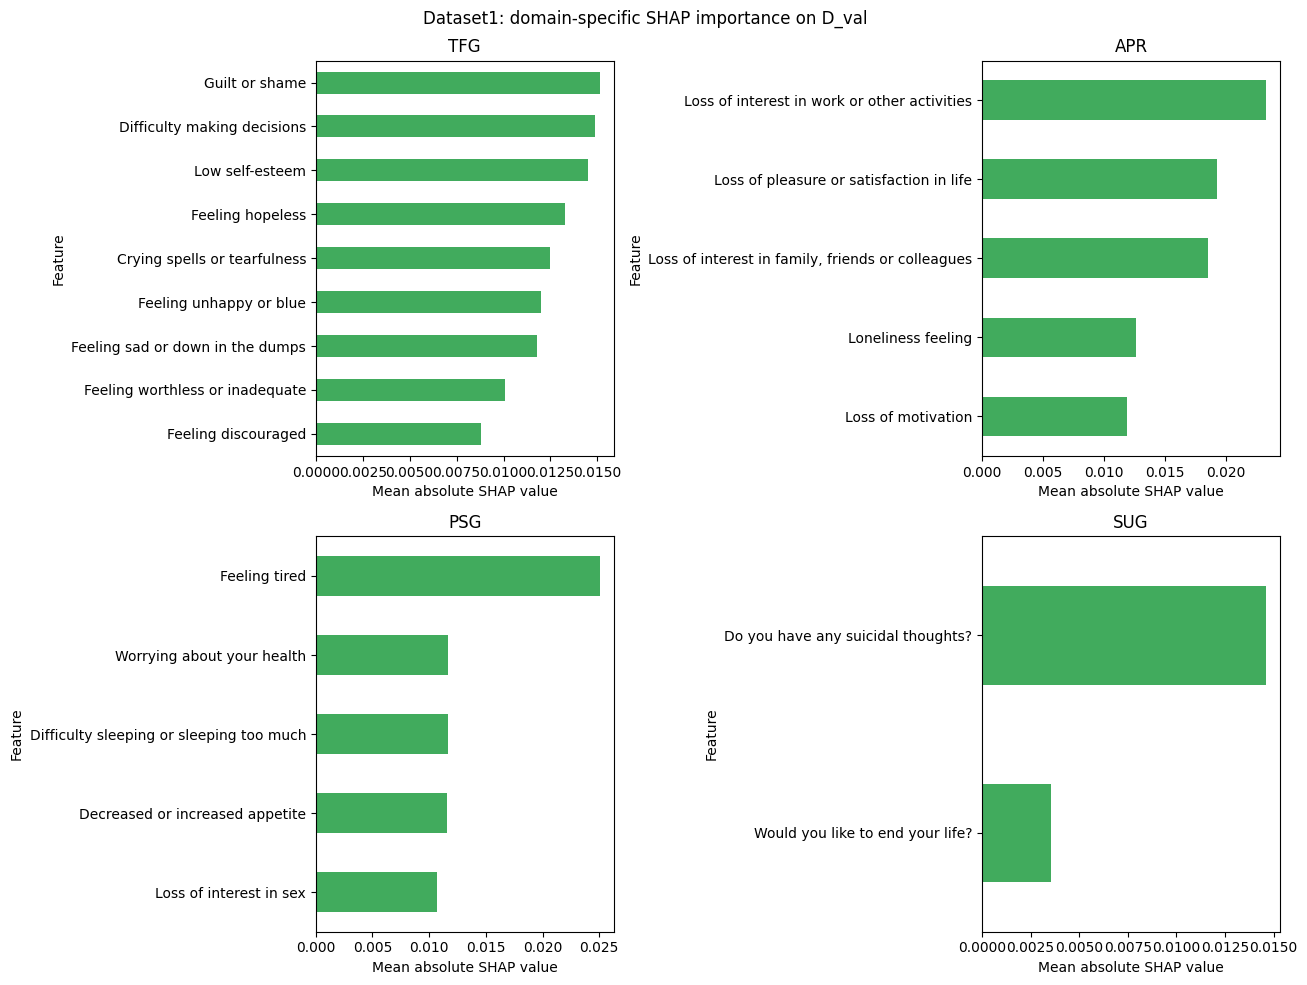


=== Dataset2: SHAP importance on D_val ===


,Mean Absolute SHAP
Difficulty sleeping or sleeping too much,0.021282
Spending less time with family or friends,0.021083
Low self-esteem,0.020617
Loneliness feeling,0.020589
Do you have a plan for harming yourself?,0.018486
Do you have any suicidal thoughts?,0.018460
Avoiding work or other activities,0.018162
Feeling unhappy or blue,0.018042
Crying spells or tearfulness,0.017954
Feeling discouraged,0.017899


Domain-level SHAP ranking:


,Domain,Feature,Mean Absolute SHAP
11,APR,Spending less time with family or friends,0.021083
10,APR,Loneliness feeling,0.020589
14,APR,Avoiding work or other activities,0.018162
9,APR,"Loss of interest in family, friends or colleagues",0.017414
12,APR,Loss of motivation,0.016971
13,APR,Loss of interest in work or other activities,0.016369
16,PSG,Difficulty sleeping or sleeping too much,0.021282
15,PSG,Feeling tired,0.017867
18,PSG,Loss of interest in sex,0.017118
17,PSG,Decreased or increased appetite,0.015867


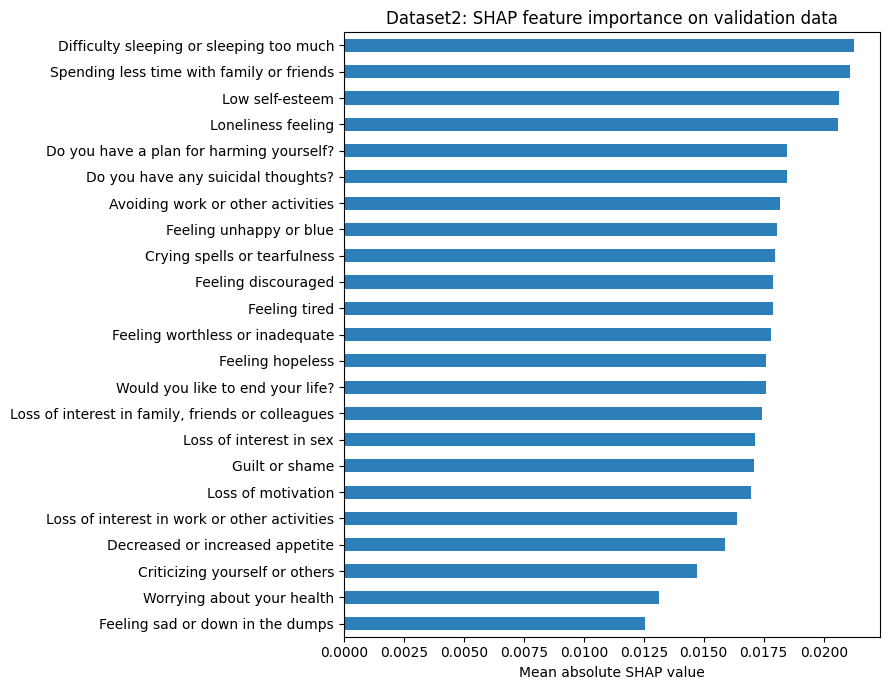

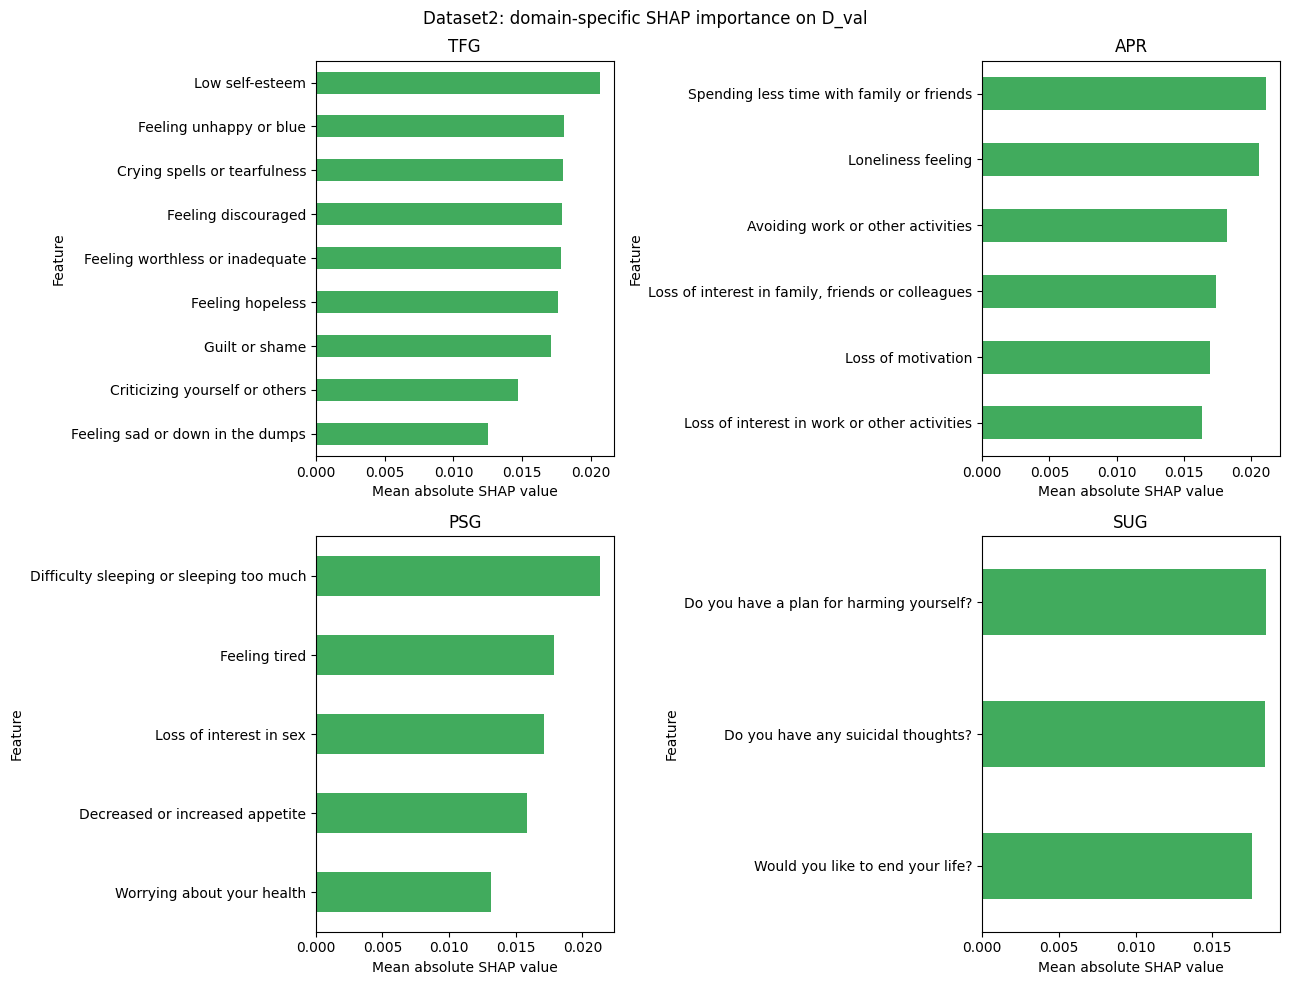

In [ ]:
if RUN_SHAP:
    import shap

    os.makedirs("/content/pfs_review_outputs", exist_ok=True)

    for name in DATASETS:
        d = DATA[name]
        features = d["selected_features"]
        model = d["locked_model"]
        X_train = d["train_df"][features]
        X_val = d["val_df"][features]

        background = shap.sample(
            X_train, min(SHAP_BACKGROUND_SIZE, len(X_train)),
            random_state=RANDOM_STATE
        )
        X_explain = X_val.sample(
            min(SHAP_MAX_SAMPLES, len(X_val)),
            random_state=RANDOM_STATE
        )

        def predict_function(values):
            frame = pd.DataFrame(values, columns=features)
            if hasattr(model, "predict_proba"):
                return model.predict_proba(frame)
            return model.predict(frame)

        explainer = shap.Explainer(
            predict_function, background, algorithm="permutation"
        )
        explanation = explainer(
            X_explain,
            max_evals=max(2 * len(features) + 1, 101),
            silent=True
        )
        values = np.asarray(explanation.values)
        if values.ndim == 3:
            importance = np.abs(values).mean(axis=(0, 2))
        else:
            importance = np.abs(values).mean(axis=0)

        ranking = pd.Series(
            importance, index=features, name="Mean Absolute SHAP"
        ).sort_values(ascending=False)
        domain_rows = []
        for group_name, group_features in GROUPS.items():
            present = [f for f in group_features if f in ranking.index]
            for feature in present:
                domain_rows.append({
                    "Domain": group_name,
                    "Feature": feature,
                    "Mean Absolute SHAP": ranking.loc[feature],
                })
        domain_ranking = pd.DataFrame(domain_rows).sort_values(
            ["Domain", "Mean Absolute SHAP"], ascending=[True, False]
        )

        d.update(
            shap_explanation=explanation,
            shap_validation_ranking=ranking,
            shap_domain_ranking=domain_ranking,
            shap_validation_sample=X_explain,
        )

        print(f"\n=== {name}: SHAP importance on D_val ===")
        display(ranking.to_frame().round(6))
        print("Domain-level SHAP ranking:")
        display(domain_ranking.round(6))

        plt.figure(figsize=(9, 7))
        ranking.sort_values().plot(kind="barh", color="#2c7fb8")
        plt.xlabel("Mean absolute SHAP value")
        plt.title(f"{name}: SHAP feature importance on validation data")
        plt.tight_layout()
        plt.savefig(
            f"/content/pfs_review_outputs/{name.lower()}_shap_global.png",
            dpi=300, bbox_inches="tight"
        )
        plt.show()

        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        for ax, group_name in zip(axes.ravel(), GROUPS):
            subset = domain_ranking[domain_ranking["Domain"] == group_name]
            if not subset.empty:
                subset.set_index("Feature")["Mean Absolute SHAP"].sort_values().plot(
                    kind="barh", ax=ax, color="#41ab5d"
                )
            ax.set_title(group_name)
            ax.set_xlabel("Mean absolute SHAP value")
        fig.suptitle(f"{name}: domain-specific SHAP importance on D_val")
        plt.tight_layout()
        plt.savefig(
            f"/content/pfs_review_outputs/{name.lower()}_shap_by_domain.png",
            dpi=300, bbox_inches="tight"
        )
        plt.show()
else:
    print("SHAP skipped. Set RUN_SHAP=True and rerun this cell if required.")

## Export reviewer and manuscript tables

In [ ]:
os.makedirs("/content/pfs_review_outputs", exist_ok=True)

FINAL_RESULTS.to_csv(
    "/content/pfs_review_outputs/final_locked_test_results.csv", index=False
)

for name, d in DATA.items():
    safe = name.lower()
    d["imputation_report"].to_csv(
        f"/content/pfs_review_outputs/{safe}_training_imputation_report.csv"
    )
    d["topk_summary"].to_csv(
        f"/content/pfs_review_outputs/{safe}_topk_validation_scores.csv", index=False
    )
    d["selected_feature_table"].to_csv(
        f"/content/pfs_review_outputs/{safe}_selected_features.csv", index=False
    )
    d["tuning_comparison"].to_csv(
        f"/content/pfs_review_outputs/{safe}_tuning_validation_comparison.csv", index=False
    )
    d["final_classification_report"].to_csv(
        f"/content/pfs_review_outputs/{safe}_final_classification_report.csv"
    )
    if "ablation" in d:
        d["ablation"].to_csv(
            f"/content/pfs_review_outputs/{safe}_validation_ablation.csv", index=False
        )
    d["cfs_rfe_results"].to_csv(
        f"/content/pfs_review_outputs/{safe}_cfs_rfe_validation_results.csv", index=False
    )
    d["classifier_accuracy_comparison"].to_csv(
        f"/content/pfs_review_outputs/{safe}_matched_classifier_accuracies.csv"
    )
    d["condition_validation_summary"].to_csv(
        f"/content/pfs_review_outputs/{safe}_condition_summary.csv", index=False
    )
    d["wilcoxon_results"].to_csv(
        f"/content/pfs_review_outputs/{safe}_wilcoxon_holm_results.csv", index=False
    )
    d["random_grouping_results"].to_csv(
        f"/content/pfs_review_outputs/{safe}_random_grouping_trials.csv", index=False
    )
    d["random_grouping_summary"].to_csv(
        f"/content/pfs_review_outputs/{safe}_random_grouping_summary.csv", index=False
    )
    if "shap_validation_ranking" in d:
        d["shap_validation_ranking"].to_csv(
            f"/content/pfs_review_outputs/{safe}_shap_validation_ranking.csv"
        )
        d["shap_domain_ranking"].to_csv(
            f"/content/pfs_review_outputs/{safe}_shap_domain_ranking.csv", index=False
        )

!cd /content && zip -qr PFS_Extended_Review_Outputs.zip pfs_review_outputs
print("Saved: /content/PFS_Extended_Review_Outputs.zip")
files.download("/content/PFS_Extended_Review_Outputs.zip")

Saved: /content/PFS_Extended_Review_Outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation rules for manuscript revision

- Replace the previously reported 94.57% and 86.40% values if the corrected locked test results differ.
- Report the exact selected percentage, feature count, feature identities and validation-selected classifier for each dataset.
- Describe Top-K as the final main PFS stage, not as a supplementary experiment. The fixed 80% setting appears only as the pre-optimization ablation reference.
- Explain the former 93.09%, 86.18% and 89.67% values only as earlier configurations if they remain relevant. Do not present them as directly comparable unless their split, selected features, SMOTE placement and evaluation partition match.
- State that imputation means were estimated from `D_train`, SMOTE was fitted separately within each CV training fold during tuning, configuration choices used `D_val`, and the locked model was evaluated once on `D_test`.